# Task 2: Thematic Analysis

**Input:** `data/clean/reviews_sentiment.csv`  
**Output:** `data/clean/reviews_final.csv`

**Approach:**
- **TF-IDF** — extracts statistically significant keywords and bigrams per bank
- **spaCy** — extracts dominant nouns and noun phrases per bank
- **Theme Mapping** — keywords grouped into 3–5 business-relevant themes per bank

**Analysis is performed per bank** to ensure themes reflect each bank's specific user feedback rather than a generic combined view.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from scripts.thematic import (
    preprocess_text,
    extract_tfidf_keywords,
    extract_spacy_keywords,
    assign_theme,
    run_thematic_analysis,
    BANK_THEME_MAPS,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Load Sentiment Data

In [2]:
df = pd.read_csv("../data/clean/reviews_sentiment.csv")

print(f"Shape: {df.shape}")
print(f"\nReviews per bank:")
print(df["bank"].value_counts())
df.head()

Shape: (1800, 10)

Reviews per bank:
bank
Commercial Bank of Ethiopia    600
Bank of Abyssinia              600
Dashen Bank                    600
Name: count, dtype: int64


,review,rating,date,bank,source,vader_score,vader_label,distilbert_label,distilbert_score,labels_agree
0,it's a good application,5,2026-05-13,Commercial Bank of Ethiopia,Google Play,0.4404,positive,positive,0.999866,True
1,thank you cbe,5,2026-05-13,Commercial Bank of Ethiopia,Google Play,0.3612,positive,positive,0.999756,True
2,is good,5,2026-05-13,Commercial Bank of Ethiopia,Google Play,0.4404,positive,positive,0.999839,True
3,wow,5,2026-05-13,Commercial Bank of Ethiopia,Google Play,0.5859,positive,positive,0.999592,True
4,Good application,2,2026-05-13,Commercial Bank of Ethiopia,Google Play,0.4404,positive,positive,0.999855,True


## 2. Keyword Extraction per Bank

For each bank we extract:
1. **TF-IDF keywords** — terms that are statistically important to that bank's reviews specifically
2. **spaCy nouns** — dominant product/service-related nouns from the raw reviews

These keywords informed the theme maps defined in `scripts/thematic.py`.

In [3]:
for bank_name in df["bank"].unique():
    bank_df = df[df["bank"] == bank_name].copy()
    bank_df["clean_text"] = bank_df["review"].apply(preprocess_text)

    print(f"\n{'='*60}")
    print(f"Bank: {bank_name}")
    print(f"{'='*60}")

    tfidf_kws = extract_tfidf_keywords(bank_df["clean_text"].tolist(), top_n=20)
    print(f"\nTop TF-IDF Keywords:")
    for kw, score in tfidf_kws:
        print(f"  {kw:<35} {score:.4f}")

    spacy_kws = extract_spacy_keywords(bank_df["review"].tolist(), top_n=20)
    print(f"\nTop spaCy Nouns:")
    for kw, count in spacy_kws:
        print(f"  {kw:<35} {count}")


Bank: Commercial Bank of Ethiopia

Top TF-IDF Keywords:
  good                                0.1852
  app                                 0.0801
  nice                                0.0587
  best                                0.0560
  cbe                                 0.0254
  like                                0.0232
  application                         0.0206
  bank                                0.0205
  service                             0.0202
  working                             0.0197
  use                                 0.0195
  update                              0.0181
  nice app                            0.0176
  easy                                0.0172
  excellent                           0.0170
  fast                                0.0164
  work                                0.0160
  good app                            0.0149
  transaction                         0.0147
  transfer                            0.0135

Top spaCy Nouns:
  app                    

## 3. Theme Grouping Logic

Based on the keywords extracted above, reviews are grouped into the following themes per bank.

### Commercial Bank of Ethiopia (CBE)
| Theme | Keyword Examples |
|-------|-----------------|
| Account Access Issues | login, password, otp, access, locked, verification |
| Transaction Performance | transfer, transaction, send, payment, failed, pending |
| App Stability | crash, freeze, bug, error, stuck, force, working, update |
| UI & Design | ui, interface, design, easy, navigation, fast, smooth |
| Customer Support | support, service, help, response, agent, complain |
| Positive Experience | good, great, excellent, best, nice, love, like, works |
| Negative Experience | worst, bad, terrible, horrible, useless, disappoint |

### Bank of Abyssinia (BOA)
| Theme | Keyword Examples |
|-------|-----------------|
| Login & Authentication | login, otp, password, sign, verification, fingerprint |
| Transaction Issues | transfer, payment, send, failed, pending, delay, balance |
| App Stability & Bugs | crash, freeze, bug, error, update, fix, problem, phone |
| UI & User Experience | ui, interface, design, easy, simple, fast, smooth |
| Feature Requests | feature, add, need, want, improve, upgrade, missing |
| Positive Experience | good, great, excellent, best, nice, love, like, works |
| Negative Experience | worst, bad, terrible, horrible, useless, disappoint |

### Dashen Bank
| Theme | Keyword Examples |
|-------|-----------------|
| Account & Login Problems | login, password, otp, access, locked, account |
| Transfer & Payment Issues | transfer, payment, send, money, failed, pending, balance |
| App Performance | crash, freeze, bug, slow, error, update, problem |
| UI & Design | ui, interface, design, easy, simple, fast, super, smooth |
| Customer Service | support, service, help, agent, complain, resolve |
| Positive Experience | good, great, excellent, best, nice, love, like, works |
| Negative Experience | worst, bad, terrible, horrible, useless, disappoint |

**Grouping Logic:** Keywords were clustered by semantic similarity and business domain. For example, `login`, `otp`, `password`, and `verification` all relate to the authentication flow and map to the same theme. Terms like `crash`, `freeze`, and `bug` indicate technical instability and form the stability theme. `Positive Experience` and `Negative Experience` capture short generic reviews that express overall satisfaction or dissatisfaction without referencing a specific feature.

## 4. Run Thematic Analysis

In [4]:
df = run_thematic_analysis(df)

print("\n=== Theme Distribution (All Banks) ===")
print(df["identified_theme"].value_counts())


Bank: Commercial Bank of Ethiopia (600 reviews)

[TF-IDF] Top keywords:
  good                           0.1852
  app                            0.0801
  nice                           0.0587
  best                           0.0560
  cbe                            0.0254
  like                           0.0232
  application                    0.0206
  bank                           0.0205
  service                        0.0202
  working                        0.0197
  use                            0.0195
  update                         0.0181
  nice app                       0.0176
  easy                           0.0172
  excellent                      0.0170

[spaCy] Top noun keywords:
  app                            118
  cbe                            25
  bank                           24
  application                    20
  service                        19
  transaction                    18
  update                         14
  transfer                       14
  time    

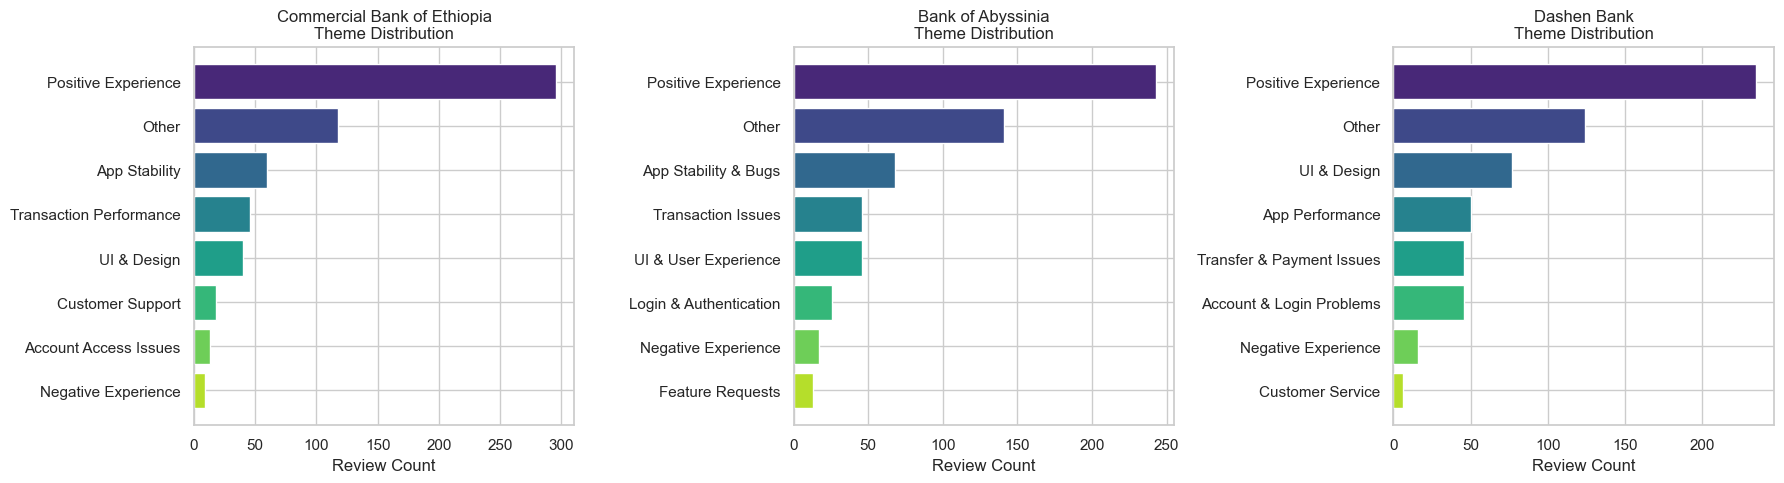

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, bank_name in enumerate(df["bank"].unique()):
    bank_df = df[df["bank"] == bank_name]
    theme_counts = bank_df["identified_theme"].value_counts()

    axes[i].barh(theme_counts.index, theme_counts.values, color=sns.color_palette("viridis", len(theme_counts)))
    axes[i].set_title(f"{bank_name}\nTheme Distribution")
    axes[i].set_xlabel("Review Count")
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Theme Sentiment Analysis

For each bank we look at the average sentiment score per theme to identify drivers (positive themes) and pain points (negative themes).

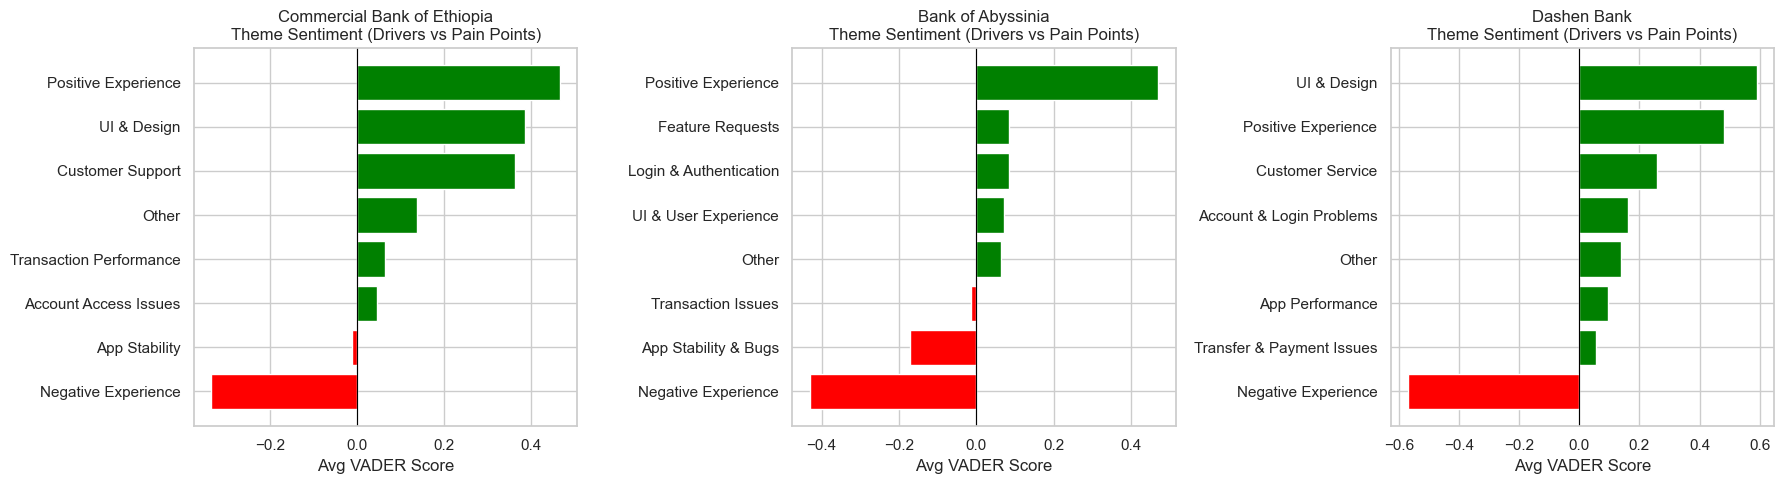

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, bank_name in enumerate(df["bank"].unique()):
    bank_df = df[df["bank"] == bank_name]
    theme_sentiment = bank_df.groupby("identified_theme")["vader_score"].mean().sort_values()

    colors = ["red" if x < 0 else "green" for x in theme_sentiment.values]
    axes[i].barh(theme_sentiment.index, theme_sentiment.values, color=colors)
    axes[i].axvline(0, color="black", linewidth=0.8)
    axes[i].set_title(f"{bank_name}\nTheme Sentiment (Drivers vs Pain Points)")
    axes[i].set_xlabel("Avg VADER Score")

plt.tight_layout()
plt.show()

## 6. Export Final Dataset

In [6]:
final_cols = [
    "review", "rating", "date", "bank", "source",
    "vader_score", "vader_label",
    "distilbert_label", "distilbert_score",
    "identified_theme",
]

df_final = df[final_cols].reset_index(drop=True)
df_final.insert(0, "review_id", df_final.index + 1)

os.makedirs("../data/clean", exist_ok=True)
df_final.to_csv("../data/clean/reviews_final.csv", index=False)
print(f"Saved {len(df_final)} reviews → data/clean/reviews_final.csv")
print(f"\nFinal columns: {list(df_final.columns)}")
df_final.head()

Saved 1800 reviews → data/clean/reviews_final.csv

Final columns: ['review_id', 'review', 'rating', 'date', 'bank', 'source', 'vader_score', 'vader_label', 'distilbert_label', 'distilbert_score', 'identified_theme']


,review_id,review,rating,date,bank,source,vader_score,vader_label,distilbert_label,distilbert_score,identified_theme
0,1,it's a good application,5,2026-05-13,Commercial Bank of Ethiopia,Google Play,0.4404,positive,positive,0.999866,Positive Experience
1,2,thank you cbe,5,2026-05-13,Commercial Bank of Ethiopia,Google Play,0.3612,positive,positive,0.999756,Positive Experience
2,3,is good,5,2026-05-13,Commercial Bank of Ethiopia,Google Play,0.4404,positive,positive,0.999839,Positive Experience
3,4,wow,5,2026-05-13,Commercial Bank of Ethiopia,Google Play,0.5859,positive,positive,0.999592,Other
4,5,Good application,2,2026-05-13,Commercial Bank of Ethiopia,Google Play,0.4404,positive,positive,0.999855,Positive Experience
